In [ ]:
import os
import cv2
import pytesseract
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import json
try:
    from tqdm import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    print("Warning: tqdm not available, using basic progress tracking")
import warnings

warnings.filterwarnings('ignore')

# Configure Tesseract path for Windows
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [ ]:
# Define paths
PROCESSED_IMAGES_PATH = r"D:\SEM6\DL\DARK\processed_images"
OUTPUT_PATH = r"D:\SEM6\DL\DARK\training"
ANNOTATED_IMAGES_PATH = os.path.join(OUTPUT_PATH, "annotated_images")
RESULTS_PATH = os.path.join(OUTPUT_PATH, "ocr_results")

# Create output directories
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(ANNOTATED_IMAGES_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

# Load list of preprocessed images
image_files = sorted([f for f in os.listdir(PROCESSED_IMAGES_PATH) if f.endswith('.png')])
print(f"✓ Found {len(image_files)} preprocessed images")
print(f"  Sample images: {image_files[:5]}")

# Load a sample image to check dimensions
sample_img = cv2.imread(os.path.join(PROCESSED_IMAGES_PATH, image_files[0]), cv2.IMREAD_GRAYSCALE)
print(f"  Image dimensions: {sample_img.shape}")

✓ Found 1000 preprocessed images
  Sample images: ['0001.png', '0002.png', '0003.png', '0004.png', '0005.png']
  Image dimensions: (4096, 4096)


In [ ]:
# Tesseract configuration for optimal text detection
# PSM (Page Segmentation Mode) options:
# 0 = Orientation and script detection only
# 1 = Automatic page segmentation with OSD
# 3 = Fully automatic page segmentation (default)
# 6 = Uniform block of text
# 11 = Sparse text
# 13 = Raw line (treat the image as a single text line)

TESSERACT_CONFIG = r'--psm 3 --oem 3 -c tessedit_char_blacklist=^'

# Alternative configs for different scenarios:
configs = {
    'default': r'--psm 3 --oem 3',
    'single_line': r'--psm 7 --oem 3',
    'sparse_text': r'--psm 11 --oem 3',
    'raw_line': r'--psm 13 --oem 3',
}

print("✓ Tesseract configurations initialized")
print(f"  Using default config: {TESSERACT_CONFIG}")
print(f"  Available configs: {list(configs.keys())}")

✓ Tesseract configurations initialized
  Using default config: --psm 3 --oem 3 -c tessedit_char_blacklist=^
  Available configs: ['default', 'single_line', 'sparse_text', 'raw_line']


In [ ]:
def extract_text_and_boxes(image_path, config=TESSERACT_CONFIG):
    """
    Extract text and bounding boxes from image using Tesseract
    Returns: text, boxes with coordinates, confidence scores
    """
    try:
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            return None, None, None
        
        # Convert to RGB for pytesseract
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Get detailed text data using image_to_data
        data = pytesseract.image_to_data(rgb_image, config=config, output_type=pytesseract.Output.DICT)
        
        # Extract text and bounding boxes
        extracted_text = []
        boxes = []
        confidences = []
        
        for i in range(len(data['text'])):
            text = data['text'][i]
            conf = int(data['conf'][i])
            
            # Filter out empty text and low confidence
            if text.strip() and conf > 0:
                x = int(data['left'][i])
                y = int(data['top'][i])
                w = int(data['width'][i])
                h = int(data['height'][i])
                
                extracted_text.append(text)
                boxes.append({'x': x, 'y': y, 'w': w, 'h': h, 'x2': x+w, 'y2': y+h})
                confidences.append(conf)
        
        return extracted_text, boxes, confidences
    
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return None, None, None

# Process a sample image first
print("Processing sample image...")
sample_path = os.path.join(PROCESSED_IMAGES_PATH, image_files[0])
text, boxes, conf = extract_text_and_boxes(sample_path)

print(f"✓ Sample image processed")
print(f"  Detected text: {text[:3] if text else 'None'}...")
print(f"  Number of text regions: {len(boxes) if boxes else 0}")
if conf:
    print(f"  Average confidence: {np.mean(conf):.2f}%")

Processing sample image...
✓ Sample image processed
  Detected text: ['o)', 'RELEASES', 'BLOG']...
  Number of text regions: 135
  Average confidence: 87.90%


Generating visualization...


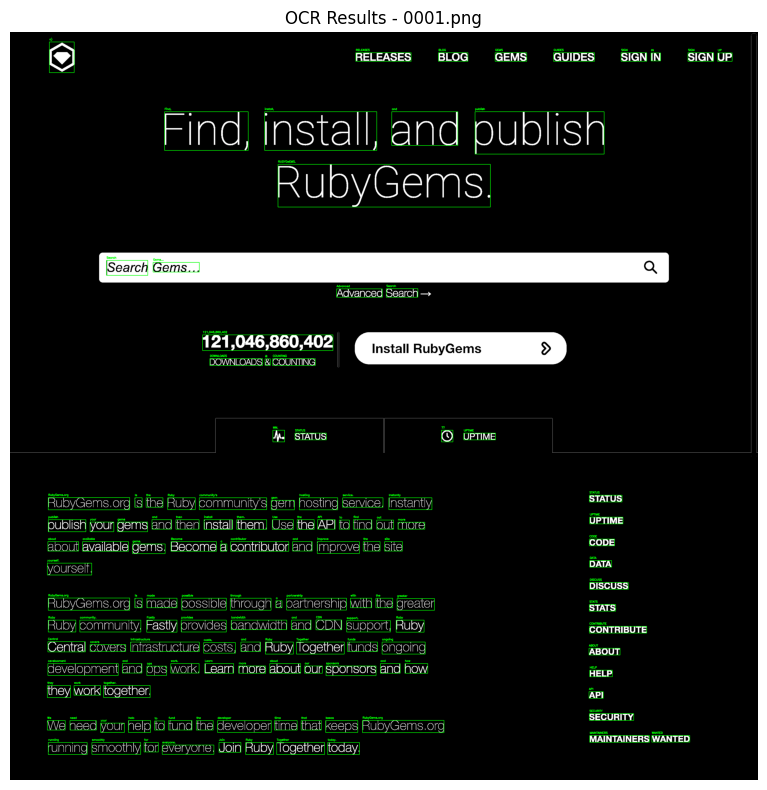

✓ Sample visualization saved


In [ ]:
def visualize_ocr_results(image_path, texts, boxes, output_path=None):
    """
    Visualize OCR results by drawing bounding boxes on the image
    """
    if texts is None or boxes is None:
        return None
    
    try:
        image = cv2.imread(image_path)
        img_copy = image.copy()
        
        for text, box in zip(texts, boxes):
            # Draw rectangle
            pt1 = (box['x'], box['y'])
            pt2 = (box['x2'], box['y2'])
            cv2.rectangle(img_copy, pt1, pt2, (0, 255, 0), 2)
            
            # Put text label
            cv2.putText(img_copy, text, (box['x'], box['y']-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        if output_path:
            cv2.imwrite(output_path, img_copy)
        
        return img_copy
    except Exception as e:
        print(f"Visualization error: {e}")
        return None

# Visualize sample result
print("Generating visualization...")
sample_annotated = visualize_ocr_results(
    sample_path, 
    text, 
    boxes,
    os.path.join(ANNOTATED_IMAGES_PATH, f"{image_files[0]}")
)

if sample_annotated is not None:
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(sample_annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"OCR Results - {image_files[0]}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("✓ Sample visualization saved")
else:
    print("✗ Visualization failed")

In [ ]:
# Process all images
print("Starting batch OCR processing...")
print(f"Processing {len(image_files)} images...")

all_results = []
processed_count = 0
error_count = 0

# Use tqdm if available, otherwise use basic range
if HAS_TQDM:
    iterator = tqdm(image_files, desc="Processing images")
else:
    iterator = image_files
    print("Processing images (no progress bar available)...")

for idx, img_file in enumerate(iterator):
    img_path = os.path.join(PROCESSED_IMAGES_PATH, img_file)
    
    # Extract text and boxes
    texts, boxes, confidences = extract_text_and_boxes(img_path)
    
    if texts is not None:
        processed_count += 1
        
        # Full text from all detections
        full_text = " ".join(texts) if texts else ""
        
        # Store results
        result = {
            'image_id': img_file.replace('.png', ''),
            'image_path': img_file,
            'detected_text': full_text,
            'text_regions': len(texts),
            'average_confidence': np.mean(confidences) if confidences else 0,
            'max_confidence': max(confidences) if confidences else 0,
            'min_confidence': min(confidences) if confidences else 0,
            'bounding_boxes': boxes,
            'individual_texts': texts,
            'confidences': confidences
        }
        
        all_results.append(result)
        
        # Save annotated image
        output_img_path = os.path.join(ANNOTATED_IMAGES_PATH, img_file)
        visualize_ocr_results(img_path, texts, boxes, output_img_path)
        
        # Save detailed results as JSON
        json_path = os.path.join(RESULTS_PATH, f"{img_file.replace('.png', '')}.json")
        with open(json_path, 'w') as f:
            # Convert non-serializable objects
            json_result = result.copy()
            json_result['confidences'] = [int(c) for c in json_result['confidences']]
            json.dump(json_result, f, indent=2)
    else:
        error_count += 1

print(f"\n✓ Batch processing completed!")
print(f"  Successfully processed: {processed_count}/{len(image_files)}")
print(f"  Errors: {error_count}")

Starting batch OCR processing...
Processing 1000 images...


Processing images: 100%|██████████| 1000/1000 [57:23<00:00,  3.44s/it] 


✓ Batch processing completed!
  Successfully processed: 1000/1000
  Errors: 0



OCR DETECTION PERFORMANCE METRICS

Dataset Statistics:
  Total images processed: 1000
  Total text regions detected: 93416
  Average text regions per image: 93.42

Confidence Scores:
  Mean average confidence: 80.73%
  Median average confidence: 87.34%
  Std deviation: 19.91%
  Max average confidence: 96.00%
  Min average confidence: 0.00%

Images with ≥50% confidence: 920/1000 (92.0%)


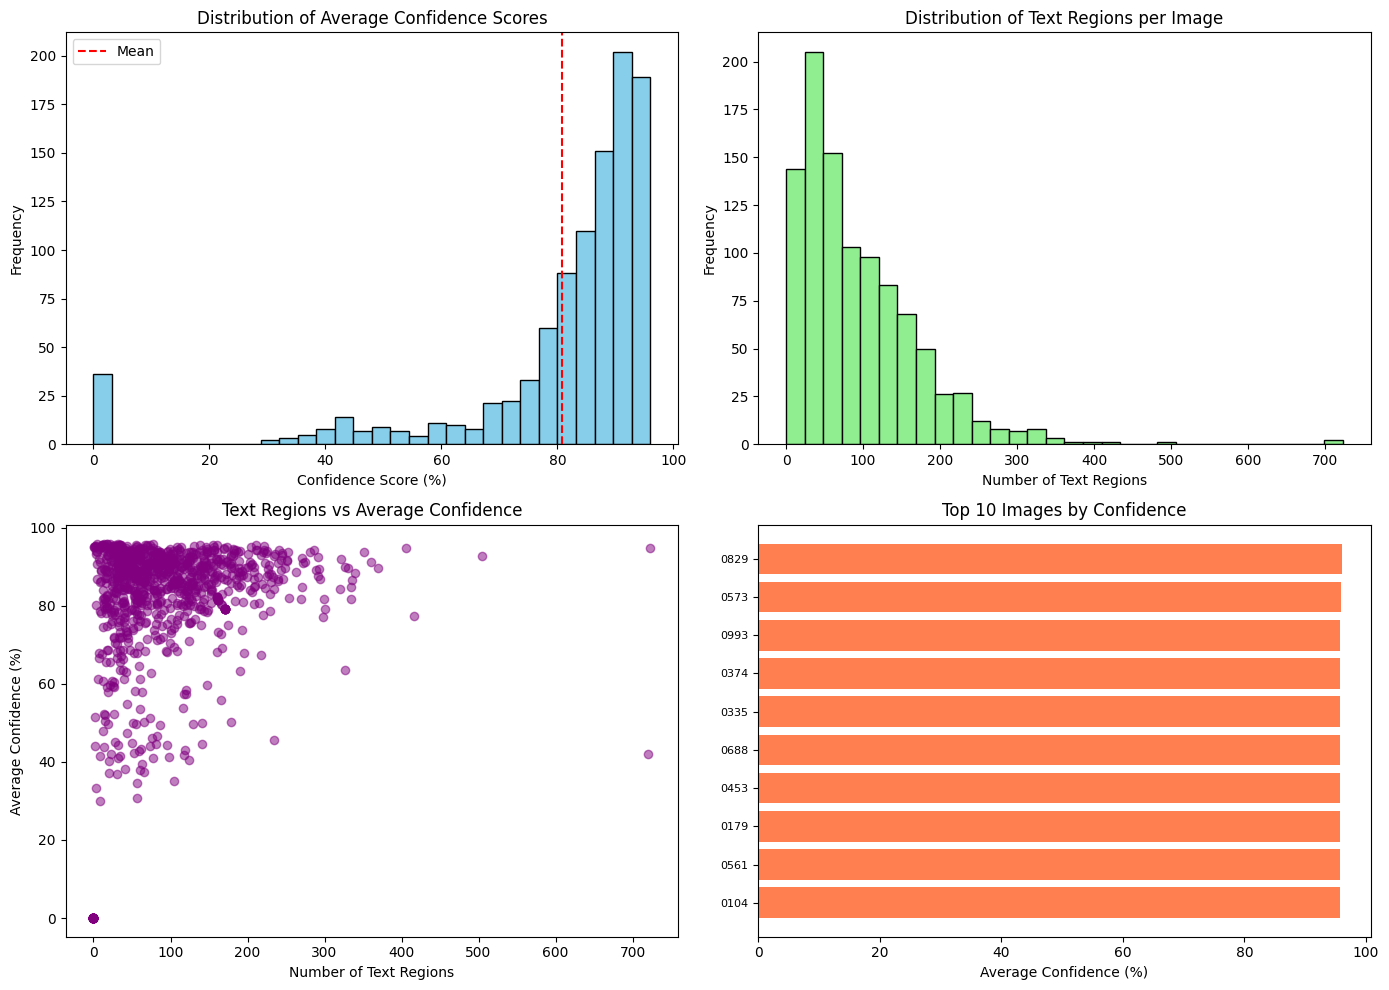


✓ Evaluation completed


In [ ]:
# Create summary statistics
print("\n" + "="*60)
print("OCR DETECTION PERFORMANCE METRICS")
print("="*60)

# Convert to DataFrame for analysis
results_df = pd.DataFrame([{
    'image_id': r['image_id'],
    'image_path': r['image_path'],
    'detected_text': r['detected_text'],
    'text_regions': r['text_regions'],
    'avg_confidence': r['average_confidence'],
    'max_confidence': r['max_confidence'],
    'min_confidence': r['min_confidence']
} for r in all_results])

# Statistics
print(f"\nDataset Statistics:")
print(f"  Total images processed: {len(results_df)}")
print(f"  Total text regions detected: {results_df['text_regions'].sum()}")
print(f"  Average text regions per image: {results_df['text_regions'].mean():.2f}")

print(f"\nConfidence Scores:")
print(f"  Mean average confidence: {results_df['avg_confidence'].mean():.2f}%")
print(f"  Median average confidence: {results_df['avg_confidence'].median():.2f}%")
print(f"  Std deviation: {results_df['avg_confidence'].std():.2f}%")
print(f"  Max average confidence: {results_df['avg_confidence'].max():.2f}%")
print(f"  Min average confidence: {results_df['avg_confidence'].min():.2f}%")

# Count images with high confidence detections
high_conf = (results_df['avg_confidence'] >= 50).sum()
print(f"\nImages with ≥50% confidence: {high_conf}/{len(results_df)} ({100*high_conf/len(results_df):.1f}%)")

# Visualization of metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribution of average confidence
axes[0, 0].hist(results_df['avg_confidence'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Average Confidence Scores')
axes[0, 0].set_xlabel('Confidence Score (%)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(results_df['avg_confidence'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# Plot 2: Text regions per image
axes[0, 1].hist(results_df['text_regions'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of Text Regions per Image')
axes[0, 1].set_xlabel('Number of Text Regions')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Correlation between text regions and confidence
axes[1, 0].scatter(results_df['text_regions'], results_df['avg_confidence'], alpha=0.5, color='purple')
axes[1, 0].set_title('Text Regions vs Average Confidence')
axes[1, 0].set_xlabel('Number of Text Regions')
axes[1, 0].set_ylabel('Average Confidence (%)')

# Plot 4: Top 10 images by confidence
top_10 = results_df.nlargest(10, 'avg_confidence')
axes[1, 1].barh(range(len(top_10)), top_10['avg_confidence'].values, color='coral')
axes[1, 1].set_yticks(range(len(top_10)))
axes[1, 1].set_yticklabels(top_10['image_id'].values, fontsize=8)
axes[1, 1].set_xlabel('Average Confidence (%)')
axes[1, 1].set_title('Top 10 Images by Confidence')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✓ Evaluation completed")

In [ ]:
# Save results to CSV
csv_path = os.path.join(OUTPUT_PATH, "ocr_results_summary.csv")
results_df.to_csv(csv_path, index=False)
print(f"✓ Results saved to CSV: {csv_path}")

# Save detailed results to JSON
all_results_json_path = os.path.join(OUTPUT_PATH, "ocr_results_detailed.json")
with open(all_results_json_path, 'w') as f:
    json_data = []
    for r in all_results:
        r_copy = r.copy()
        r_copy['confidences'] = [int(c) for c in r_copy['confidences']]
        json_data.append(r_copy)
    json.dump(json_data, f, indent=2)
print(f"✓ Detailed results saved to JSON: {all_results_json_path}")

# Create a summary report
report_path = os.path.join(OUTPUT_PATH, "ocr_summary_report.txt")
with open(report_path, 'w') as f:
    f.write("="*70 + "\n")
    f.write("TESSERACT OCR TEXT DETECTION - SUMMARY REPORT\n")
    f.write("="*70 + "\n\n")
    
    f.write("DATASET INFORMATION:\n")
    f.write(f"  Preprocessed images location: {PROCESSED_IMAGES_PATH}\n")
    f.write(f"  Total images processed: {len(results_df)}\n")
    f.write(f"  Image format: PNG (grayscale)\n\n")
    
    f.write("DETECTION RESULTS:\n")
    f.write(f"  Total text regions detected: {results_df['text_regions'].sum()}\n")
    f.write(f"  Average regions per image: {results_df['text_regions'].mean():.2f}\n")
    f.write(f"  Max regions in single image: {results_df['text_regions'].max()}\n")
    f.write(f"  Min regions in single image: {results_df['text_regions'].min()}\n\n")
    
    f.write("CONFIDENCE ANALYSIS:\n")
    f.write(f"  Mean confidence score: {results_df['avg_confidence'].mean():.2f}%\n")
    f.write(f"  Median confidence score: {results_df['avg_confidence'].median():.2f}%\n")
    f.write(f"  Std deviation: {results_df['avg_confidence'].std():.2f}%\n")
    f.write(f"  Min confidence: {results_df['avg_confidence'].min():.2f}%\n")
    f.write(f"  Max confidence: {results_df['avg_confidence'].max():.2f}%\n\n")
    
    f.write("QUALITY METRICS:\n")
    high_conf_count = (results_df['avg_confidence'] >= 50).sum()
    f.write(f"  Images with >=50% confidence: {high_conf_count} ({100*high_conf_count/len(results_df):.1f}%)\n")
    very_high_conf = (results_df['avg_confidence'] >= 75).sum()
    f.write(f"  Images with >=75% confidence: {very_high_conf} ({100*very_high_conf/len(results_df):.1f}%)\n\n")
    
    f.write("OUTPUT FILES:\n")
    f.write(f"  Annotated images: {ANNOTATED_IMAGES_PATH}\n")
    f.write(f"  OCR results (JSON): {RESULTS_PATH}\n")
    f.write(f"  Summary CSV: {csv_path}\n")
    f.write(f"  Detailed JSON: {all_results_json_path}\n\n")
    
    f.write("TESSERACT CONFIGURATION:\n")
    f.write(f"  Config string: {TESSERACT_CONFIG}\n")
    f.write(f"  PSM mode: 3 (Fully automatic)\n")
    f.write(f"  OCR engine: 3 (Combined legacy + neural)\n")

print(f"✓ Summary report saved: {report_path}")

# Create training dataset format (for future deep learning models)
# COCO format-like structure
training_data = {
    'info': {
        'dataset': 'Tesseract OCR Training Dataset',
        'preprocessor': 'OpenCV (grayscale, resized, sharpened, thresholded)',
        'detector': 'Tesseract OCR',
        'total_images': int(results_df.shape[0]),
        'total_annotations': int(results_df['text_regions'].sum())
    },
    'images': [],
    'annotations': []
}

annotation_id = 1
for idx, result in enumerate(all_results):
    img_info = {
        'id': int(idx),
        'file_name': result['image_path'],
        'text': result['detected_text'],
        'text_regions': int(result['text_regions'])
    }
    training_data['images'].append(img_info)
    
    # Add bounding box annotations
    for box, text, conf in zip(result['bounding_boxes'], result['individual_texts'], result['confidences']):
        annotation = {
            'id': int(annotation_id),
            'image_id': int(idx),
            'text': text,
            'bbox': [int(box['x']), int(box['y']), int(box['w']), int(box['h'])],
            'area': int(box['w'] * box['h']),
            'confidence': int(conf),
            'category_id': 1  # Text category
        }
        training_data['annotations'].append(annotation)
        annotation_id += 1

# Save training data
training_data_path = os.path.join(OUTPUT_PATH, "training_dataset.json")
with open(training_data_path, 'w') as f:
    json.dump(training_data, f, indent=2)
print(f"✓ Training dataset (COCO-like format) saved: {training_data_path}")

print("\n" + "="*70)
print("OCR TRAINING COMPLETED SUCCESSFULLY!")
print("="*70)
print(f"\nOutput directory: {OUTPUT_PATH}")
print(f"Annotated images saved to: {ANNOTATED_IMAGES_PATH}")
print(f"Results saved to: {RESULTS_PATH}")

✓ Results saved to CSV: D:\SEM6\DL\DARK\training\ocr_results_summary.csv
✓ Detailed results saved to JSON: D:\SEM6\DL\DARK\training\ocr_results_detailed.json
✓ Summary report saved: D:\SEM6\DL\DARK\training\ocr_summary_report.txt
✓ Training dataset (COCO-like format) saved: D:\SEM6\DL\DARK\training\training_dataset.json

OCR TRAINING COMPLETED SUCCESSFULLY!

Output directory: D:\SEM6\DL\DARK\training
Annotated images saved to: D:\SEM6\DL\DARK\training\annotated_images
Results saved to: D:\SEM6\DL\DARK\training\ocr_results


In [ ]:
# Export data suitable for YOLO or other object detection frameworks
# This can be used to train custom text detection models
import os
import cv2

yolo_output_dir = os.path.join(OUTPUT_PATH, "yolo_format")
os.makedirs(os.path.join(yolo_output_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(yolo_output_dir, "labels"), exist_ok=True)

print("Exporting data in YOLO format...")

for idx, result in enumerate(all_results):
    img_id = result['image_id']
    
    # Read original image dimensions
    img_path = os.path.join(PROCESSED_IMAGES_PATH, result['image_path'])
    img = cv2.imread(img_path)
    
    if img is None:
        continue
    
    h, w = img.shape[:2]
    
    # Create YOLO format labels
    label_content = ""
    for box in result['bounding_boxes']:
        # YOLO format: class x_center y_center width height (normalized 0-1)
        x_center = (box['x'] + box['w']/2) / w
        y_center = (box['y'] + box['h']/2) / h
        width = box['w'] / w
        height = box['h'] / h
        
        # Clamp values to 0-1 range
        x_center = max(0, min(1, x_center))
        y_center = max(0, min(1, y_center))
        width = max(0, min(1, width))
        height = max(0, min(1, height))
        
        # Class 0 for text
        label_content += f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n"
    
    # Save label file
    label_path = os.path.join(yolo_output_dir, "labels", f"{img_id}.txt")
    with open(label_path, 'w') as f:
        f.write(label_content)
    
    # Copy/link image
    import shutil
    image_output_path = os.path.join(yolo_output_dir, "images", result['image_path'])
    shutil.copy(img_path, image_output_path)

print(f"✓ YOLO format data exported to: {yolo_output_dir}")

# Create classes.txt file
with open(os.path.join(yolo_output_dir, "classes.txt"), 'w') as f:
    f.write("text\n")

print("✓ YOLO format ready for training with custom text detection models")
print(f"\nNext steps:")
print(f"  1. Use YOLO format data in: {yolo_output_dir}")
print(f"  2. Train YOLOv8, YOLOv5, or custom models on text detection")
print(f"  3. Results and annotations in: {OUTPUT_PATH}")

Exporting data in YOLO format...
✓ YOLO format data exported to: D:\SEM6\DL\DARK\training\yolo_format
✓ YOLO format ready for training with custom text detection models

Next steps:
  1. Use YOLO format data in: D:\SEM6\DL\DARK\training\yolo_format
  2. Train YOLOv8, YOLOv5, or custom models on text detection
  3. Results and annotations in: D:\SEM6\DL\DARK\training
